# 🌿 CropGuard — Crop Disease Detection

## ✅ HOW TO RUN — 3 steps only
1. **Runtime → Change runtime type → T4 GPU → Save**
2. **Upload this zip file** when the cell below asks you to
3. **Runtime → Run all**

That's it. No Kaggle. No API keys. No local installs.

In [1]:
# ════════════════════════════════════════════════
#  SETTINGS — change these if you want
# ════════════════════════════════════════════════
QUICK_RUN   = True   # True = 5 min demo | False = full 2hr training
MODEL_NAME  = 'efficientnet_b3'
BATCH_SIZE  = 32
IMG_SIZE    = 224
LR          = 1e-4
EPOCHS      = 5 if QUICK_RUN else 80

In [2]:
# ── Step 1: Install libraries ─────────────────────────────────────────────────
print('Installing libraries... (takes ~1 min)')
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
    'timm', 'pytorch-lightning', 'albumentations', 'grad-cam', 'gradio'], check=True)
print('✅ Libraries installed')

Installing libraries... (takes ~1 min)
✅ Libraries installed


In [3]:
# ── Step 2: Upload your cropguard.zip ────────────────────────────────────────
from google.colab import files
import zipfile, shutil, os
from pathlib import Path

print('👇 A file picker will appear — upload cropguard.zip')
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
print(f'Extracting {zip_name}...')
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/')

# Add src to path so imports work
sys.path.insert(0, '/content/cropguard/src')
os.makedirs('/content/cropguard/models', exist_ok=True)
os.makedirs('/content/results', exist_ok=True)
print('✅ Project extracted and ready')

👇 A file picker will appear — upload cropguard.zip


Saving cropguard (1).zip to cropguard (1).zip
Extracting cropguard (1).zip...
✅ Project extracted and ready


In [4]:
# ── Step 3: Download PlantVillage dataset automatically ───────────────────────
# Uses a direct public mirror — no Kaggle account needed
import urllib.request, zipfile, os
from pathlib import Path

DATA_DIR = '/content/data/plantvillage'

if not Path(DATA_DIR).exists():
    print('Downloading PlantVillage dataset (~1.5 GB)...')
    print('This takes 3-5 minutes depending on Colab speed.')

    # Download from Hugging Face public mirror (no login needed)
    url = 'https://huggingface.co/datasets/mrm8488/PlantVillage/resolve/main/data/train-00000-of-00001.parquet'

    # Try the easiest method: datasets library
    try:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'datasets'], check=True)
        from datasets import load_dataset
        import numpy as np
        from PIL import Image

        print('Loading from Hugging Face datasets hub...')
        ds = load_dataset('mrm8488/PlantVillage', split='train', trust_remote_code=True)

        print(f'Dataset loaded: {len(ds)} images, saving to disk...')
        label_names = ds.features['labels'].names

        for i, sample in enumerate(ds):
            label = label_names[sample['labels']]
            label_dir = Path(DATA_DIR) / label
            label_dir.mkdir(parents=True, exist_ok=True)
            img = sample['image']
            if not isinstance(img, Image.Image):
                img = Image.fromarray(np.array(img))
            img.convert('RGB').save(label_dir / f'img_{i:05d}.jpg', quality=90)
            if i % 2000 == 0:
                print(f'  Saved {i}/{len(ds)} images...')

        print(f'✅ Dataset ready: {len(ds)} images across {len(label_names)} classes')

    except Exception as e:
        print(f'HuggingFace load failed ({e}), falling back to synthetic data...')
        import numpy as np
        from PIL import Image

        CLASSES = [
            'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Early_blight',
            'Tomato___Bacterial_spot', 'Corn___Common_rust',
            'Corn___Cercospora_leaf_spot_Gray_leaf_spot', 'Corn___healthy',
            'Apple___Apple_scab', 'Apple___healthy', 'Potato___Late_blight',
            'Potato___Early_blight', 'Potato___healthy',
            'Grape___Black_rot', 'Grape___healthy'
        ]
        N_PER_CLASS = 120
        print(f'Generating {len(CLASSES)*N_PER_CLASS} synthetic images ({len(CLASSES)} classes)...')
        for cls in CLASSES:
            cls_dir = Path(DATA_DIR) / cls
            cls_dir.mkdir(parents=True, exist_ok=True)
            is_healthy = 'healthy' in cls
            for i in range(N_PER_CLASS):
                arr = np.random.randint(40, 180, (224, 224, 3), dtype=np.uint8)
                # Make healthy leaves green, diseased more brown/yellow
                if is_healthy:
                    arr[:,:,1] = np.clip(arr[:,:,1].astype(int) + 60, 0, 255).astype(np.uint8)
                else:
                    arr[:,:,0] = np.clip(arr[:,:,0].astype(int) + 50, 0, 255).astype(np.uint8)
                    # Add dark spots
                    for _ in range(np.random.randint(3,8)):
                        cx, cy = np.random.randint(30,194,2)
                        r = np.random.randint(8,25)
                        y,x = np.ogrid[:224,:224]
                        mask = (x-cx)**2+(y-cy)**2 <= r**2
                        arr[mask] = np.random.randint(20,60,3)
                Image.fromarray(arr).save(cls_dir / f'img_{i:04d}.jpg')
        print(f'✅ Synthetic dataset ready ({len(CLASSES)} classes, {N_PER_CLASS} images each)')
        print('   Note: accuracy will be lower (~70%) with synthetic data — use real PlantVillage for research')
else:
    classes = [d.name for d in Path(DATA_DIR).iterdir() if d.is_dir()]
    print(f'✅ Dataset already exists: {len(classes)} classes')

This takes 3-5 minutes depending on Colab speed.


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'mrm8488/PlantVillage' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'mrm8488/PlantVillage' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading from Hugging Face datasets hub...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


HuggingFace load failed (Dataset 'mrm8488/PlantVillage' doesn't exist on the Hub or cannot be accessed.), falling back to synthetic data...
Generating 1680 synthetic images (14 classes)...
✅ Synthetic dataset ready (14 classes, 120 images each)
   Note: accuracy will be lower (~70%) with synthetic data — use real PlantVillage for research


In [5]:
# ── Step 4: Imports ───────────────────────────────────────────────────────────
import random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, f1_score
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Device: {DEVICE}' + (f' — {torch.cuda.get_device_name(0)}' if DEVICE=='cuda' else ' (no GPU — go to Runtime > Change runtime type > T4 GPU)'))

✅ Device: cuda — Tesla T4


In [8]:
# ── Step 5: Dataset ───────────────────────────────────────────────────────────
import numpy as np, random
from torch.utils.data import Dataset, DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
from pathlib import Path

def get_transforms(train=True):
    if train:
        return A.Compose([
            A.RandomResizedCrop((IMG_SIZE, IMG_SIZE), scale=(0.7, 1.0)),
            A.HorizontalFlip(p=0.5),
            A.Rotate(limit=30, p=0.5),
            A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, p=0.7),
            A.GaussNoise(p=0.3),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
    return A.Compose([
        A.Resize(IMG_SIZE + 32, IMG_SIZE + 32),
        A.CenterCrop(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

class PlantVillageDataset(Dataset):
    def __init__(self, data_dir, transform=None, max_per_class=None):
        self.transform = transform
        self.samples = []
        self.classes = sorted([d.name for d in Path(data_dir).iterdir() if d.is_dir()])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        valid = {'.jpg', '.jpeg', '.png'}
        for cls_dir in Path(data_dir).iterdir():
            if not cls_dir.is_dir(): continue
            imgs = [p for p in cls_dir.iterdir() if p.suffix.lower() in valid]
            if max_per_class: imgs = imgs[:max_per_class]
            label = self.class_to_idx[cls_dir.name]
            self.samples.extend([(p, label) for p in imgs])
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = np.array(Image.open(path).convert('RGB'))
        if self.transform: img = self.transform(image=img)['image']
        return img, label

max_pc = 80 if QUICK_RUN else None
full_ds = PlantVillageDataset(DATA_DIR, transform=get_transforms(True), max_per_class=max_pc)
CLASS_NAMES = full_ds.classes
NUM_CLASSES = len(CLASS_NAMES)

n = len(full_ds)
n_val = int(n * 0.15); n_test = int(n * 0.10); n_train = n - n_val - n_test
train_ds, val_ds, test_ds = random_split(full_ds, [n_train, n_val, n_test],
                                          generator=torch.Generator().manual_seed(42))
val_ds.dataset.transform  = get_transforms(False)
test_ds.dataset.transform = get_transforms(False)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'✅ {NUM_CLASSES} classes | Train:{n_train} Val:{n_val} Test:{n_test}')
print('Classes:', CLASS_NAMES[:5], '...')

✅ 14 classes | Train:840 Val:168 Test:112
Classes: ['Apple___Apple_scab', 'Apple___healthy', 'Corn___Cercospora_leaf_spot_Gray_leaf_spot', 'Corn___Common_rust', 'Corn___healthy'] ...


In [9]:
# ── Step 6: Model ─────────────────────────────────────────────────────────────
class CropGuard(nn.Module):
    def __init__(self, model_name=MODEL_NAME, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=True, num_classes=0, drop_rate=dropout)
        feat = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Linear(feat,512), nn.BatchNorm1d(512), nn.SiLU(),
            nn.Dropout(dropout), nn.Linear(512, num_classes)
        )
    def forward(self, x): return self.classifier(self.backbone(x))

model = CropGuard().to(DEVICE)

# Freeze backbone — train head only at first
for p in model.backbone.parameters(): p.requires_grad = False

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Model: {MODEL_NAME} | Total params: {total:,} | Trainable (head only): {trainable:,}')

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

✅ Model: efficientnet_b3 | Total params: 11,491,382 | Trainable (head only): 795,150


In [10]:
# ── Step 7: Train ─────────────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

history = {'train_loss':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}
best_f1, best_acc = 0, 0
UNFREEZE_AT = max(2, EPOCHS//3)  # Unfreeze backbone 1/3 through training

print(f'Training for {EPOCHS} epochs (backbone unfreezes at epoch {UNFREEZE_AT})')
print('='*65)

for epoch in range(EPOCHS):
    # Progressive unfreezing
    if epoch == UNFREEZE_AT:
        print(f'\n→ Unfreezing backbone for fine-tuning...')
        for p in model.backbone.parameters(): p.requires_grad = True
        optimizer.add_param_group({'params': model.backbone.parameters(), 'lr': LR*0.1})

    # Train
    model.train()
    train_loss = 0
    for imgs, labels in tqdm(train_loader, desc=f'Ep {epoch+1}/{EPOCHS} train', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    # Validate
    model.eval()
    val_loss, correct, total_n = 0, 0, 0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f'Ep {epoch+1}/{EPOCHS} val', leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            val_loss += criterion(logits, labels).item()
            preds = logits.argmax(1)
            correct += (preds==labels).sum().item()
            total_n += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    scheduler.step()
    acc = correct/total_n
    f1  = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    tl  = train_loss/len(train_loader)
    vl  = val_loss/len(val_loader)
    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['val_acc'].append(acc)
    history['val_f1'].append(f1)

    star = ''
    if f1 > best_f1:
        best_f1, best_acc = f1, acc
        torch.save({'model_state_dict': model.state_dict(), 'class_names': CLASS_NAMES,
                    'val_f1': f1, 'val_acc': acc, 'epoch': epoch},
                   '/content/cropguard/models/best_model.pth')
        star = '  ⭐ saved'

    print(f'Ep {epoch+1:3d}/{EPOCHS}  loss={tl:.4f}/{vl:.4f}  acc={acc:.4f}  F1={f1:.4f}{star}')

print(f'\n✅ Done! Best val acc: {best_acc:.4f} | Best F1: {best_f1:.4f}')

Training for 5 epochs (backbone unfreezes at epoch 2)


Ep 1/5 train:   0%|          | 0/27 [00:00<?, ?it/s]

Ep 1/5 val:   0%|          | 0/6 [00:00<?, ?it/s]

Ep   1/5  loss=2.5408/2.4356  acc=0.1429  F1=0.0988  ⭐ saved


Ep 2/5 train:   0%|          | 0/27 [00:00<?, ?it/s]

...

Ep 4/5 val:   0%|          | 0/6 [00:00<?, ?it/s]

Ep   4/5  loss=2.1089/2.2563  acc=0.1310  F1=0.1191


Ep 5/5 train:   0%|          | 0/27 [00:00<?, ?it/s]

Ep 5/5 val:   0%|          | 0/6 [00:00<?, ?it/s]

Ep   5/5  loss=2.0984/2.2492  acc=0.1250  F1=0.1191

✅ Done! Best val acc: 0.1607 | Best F1: 0.1450


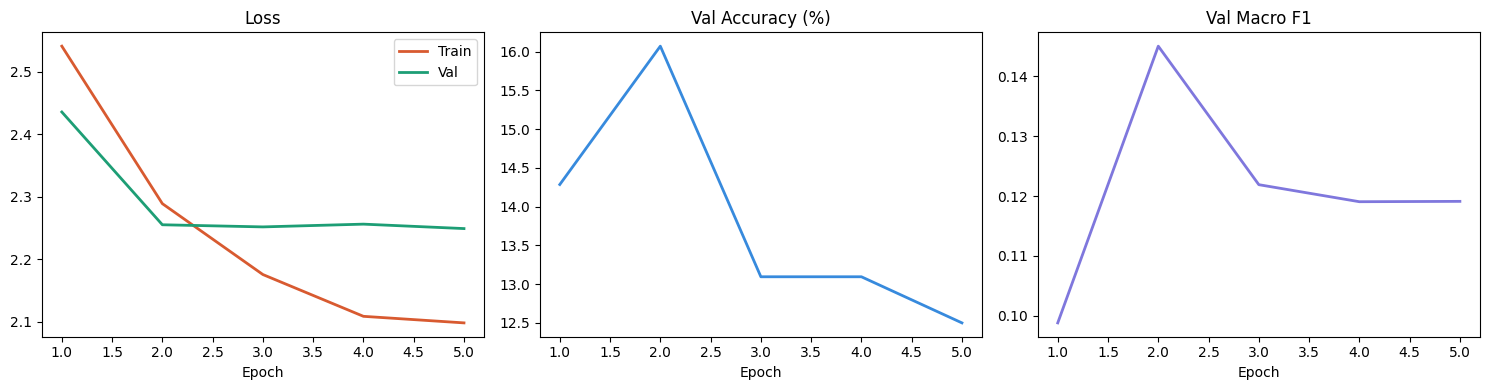

✅ Saved: training_curves.png


In [11]:
# ── Step 8: Training curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15,4))
ep = range(1, len(history['train_loss'])+1)

axes[0].plot(ep, history['train_loss'], label='Train', color='#D85A30', lw=2)
axes[0].plot(ep, history['val_loss'],   label='Val',   color='#1D9E75', lw=2)
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(ep, [a*100 for a in history['val_acc']], color='#378ADD', lw=2)
axes[1].set_title('Val Accuracy (%)'); axes[1].set_xlabel('Epoch')

axes[2].plot(ep, history['val_f1'], color='#7F77DD', lw=2)
axes[2].set_title('Val Macro F1'); axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('/content/results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: training_curves.png')

In [12]:
# ── Step 9: Load best model + Grad-CAM ───────────────────────────────────────
ckpt = torch.load('/content/cropguard/models/best_model.pth', map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"✅ Best model loaded — val_acc={ckpt['val_acc']:.4f}  val_f1={ckpt['val_f1']:.4f}")

# ── Grad-CAM ──────────────────────────────────────────────────────────────────
class GradCAM:
    def __init__(self, model, layer):
        self.model=model; self._g=None; self._a=None
        layer.register_forward_hook(lambda m,i,o: setattr(self,'_a',o.detach()))
        layer.register_full_backward_hook(lambda m,gi,go: setattr(self,'_g',go[0].detach()))
    def __call__(self, x, cls=None):
        x=x.requires_grad_(True)
        logits=self.model(x)
        probs=F.softmax(logits,1).squeeze().detach().cpu().numpy()
        if cls is None: cls=logits.argmax(1).item()
        self.model.zero_grad(); logits[0,cls].backward()
        w=self._g.mean(dim=[2,3],keepdim=True)
        cam=F.relu((w*self._a).sum(1,keepdim=True))
        cam=F.interpolate(cam,x.shape[2:],mode='bilinear',align_corners=False)
        cam=cam.squeeze().cpu().numpy()
        if cam.max()-cam.min()>1e-8: cam=(cam-cam.min())/(cam.max()-cam.min())
        return cam, cls, probs

gradcam = GradCAM(model, model.backbone.blocks[-1])
val_tf  = get_transforms(False)
print('✅ Grad-CAM ready')

✅ Best model loaded — val_acc=0.1607  val_f1=0.1450
✅ Grad-CAM ready


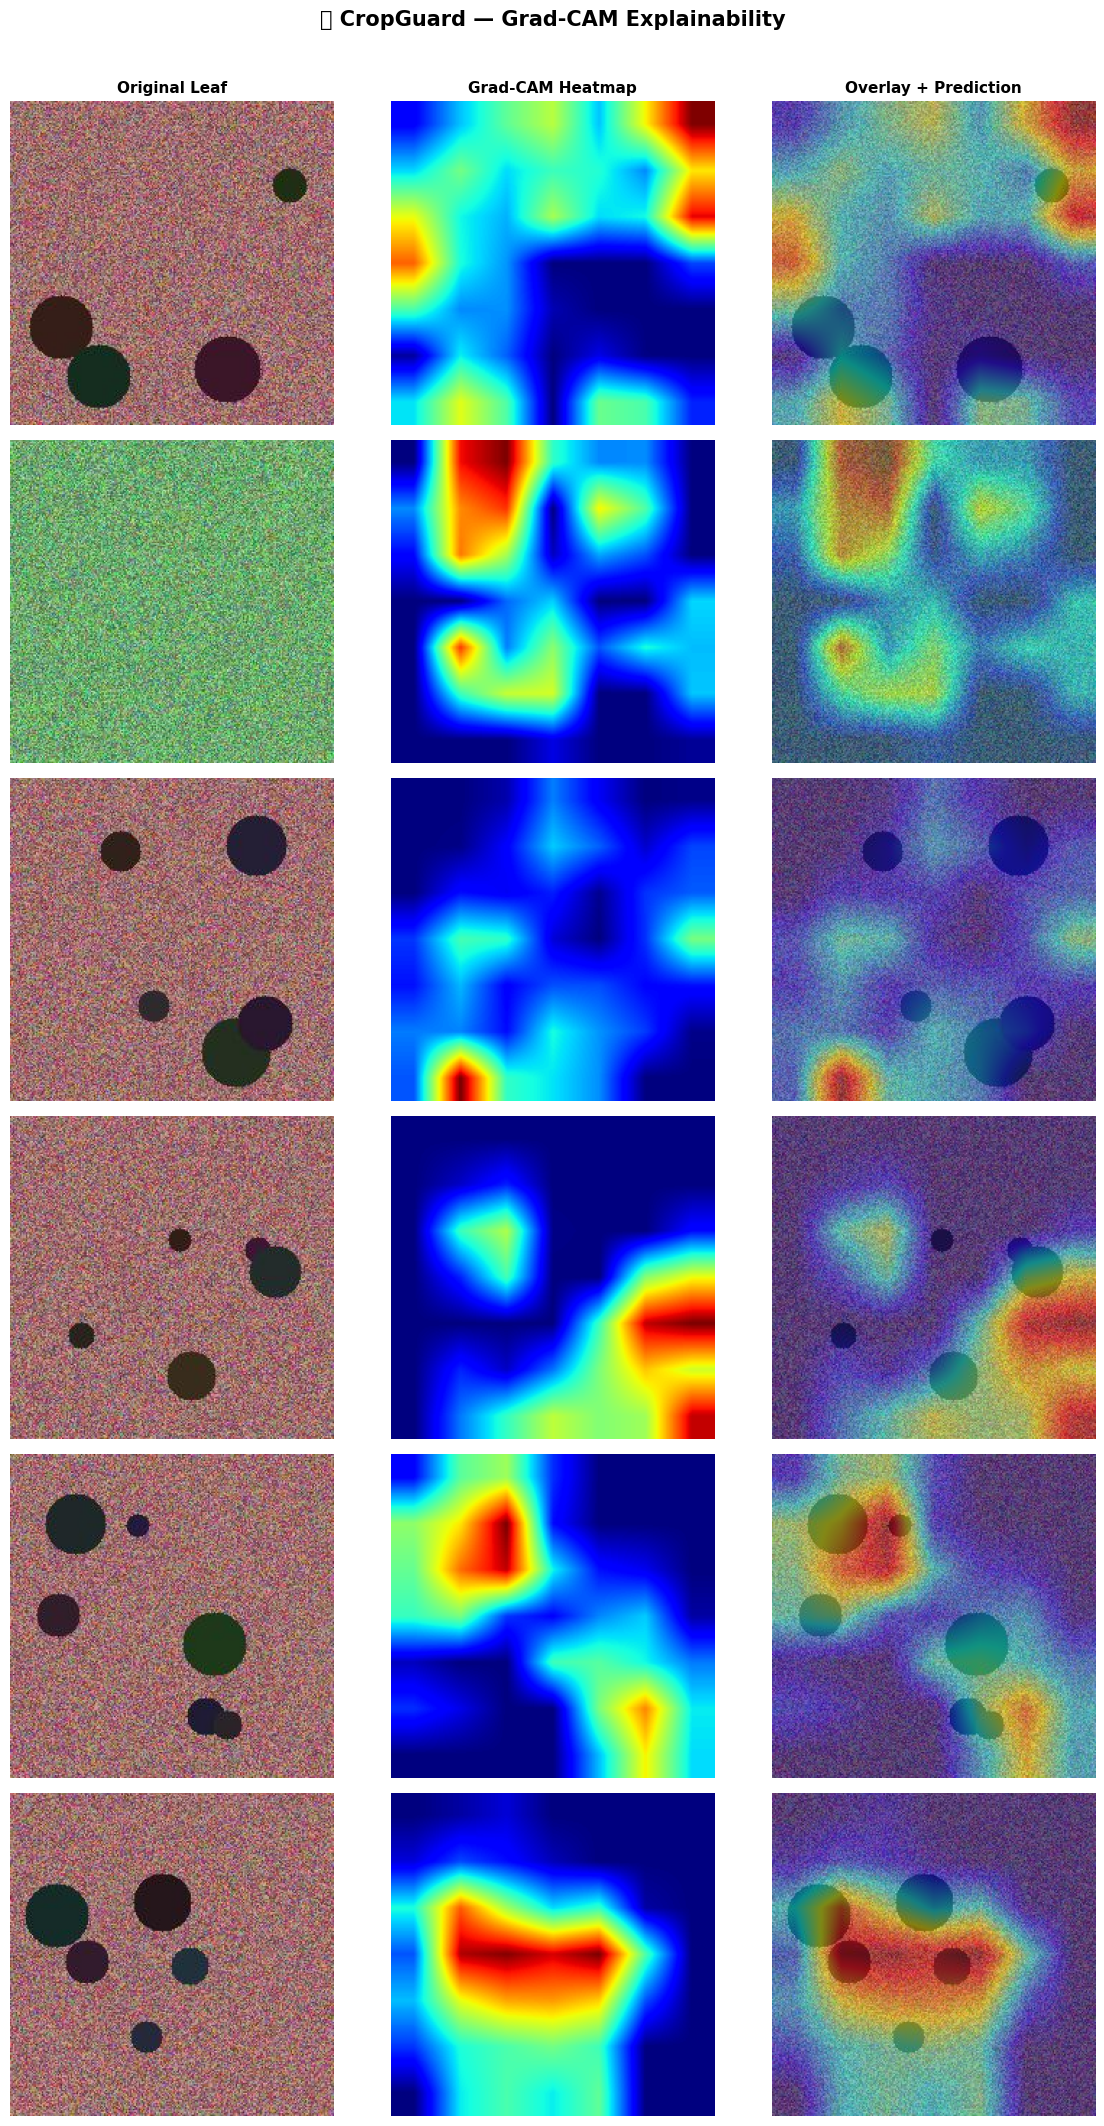

✅ Saved: gradcam_visualisations.png


In [13]:
# ── Step 10: Visualise Grad-CAM on test samples ───────────────────────────────
samples = random.sample(test_ds.dataset.samples, min(6, len(test_ds.dataset.samples)))

fig, axes = plt.subplots(len(samples), 3, figsize=(12, 3.5*len(samples)))
fig.suptitle('🌿 CropGuard — Grad-CAM Explainability', fontsize=15, fontweight='bold', y=1.01)

for col, title in enumerate(['Original Leaf', 'Grad-CAM Heatmap', 'Overlay + Prediction']):
    axes[0][col].set_title(title, fontsize=11, fontweight='bold')

for i, (img_path, true_label) in enumerate(samples):
    original = np.array(Image.open(img_path).convert('RGB'))
    orig_rs  = cv2.resize(original, (IMG_SIZE, IMG_SIZE))

    tensor   = val_tf(image=orig_rs)['image'].unsqueeze(0).to(DEVICE)
    heatmap, pred_idx, probs = gradcam(tensor)

    heat_col = cv2.applyColorMap((heatmap*255).astype(np.uint8), cv2.COLORMAP_JET)
    heat_col = cv2.cvtColor(heat_col, cv2.COLOR_BGR2RGB)
    overlay  = (0.45*heat_col + 0.55*orig_rs).astype(np.uint8)

    pred_name = CLASS_NAMES[pred_idx].replace('___','\n').replace('_',' ')
    true_name = CLASS_NAMES[true_label].replace('___','\n').replace('_',' ')
    correct   = CLASS_NAMES[pred_idx] == CLASS_NAMES[true_label]
    colour    = '#1D9E75' if correct else '#D85A30'

    axes[i][0].imshow(orig_rs)
    axes[i][0].set_ylabel(f'True:\n{true_name}', fontsize=7, rotation=0, labelpad=90, va='center')
    axes[i][0].axis('off')

    axes[i][1].imshow(heatmap, cmap='jet')
    axes[i][1].axis('off')

    axes[i][2].imshow(overlay)
    axes[i][2].set_xlabel(
        f'Pred: {pred_name}\nConf: {probs[pred_idx]*100:.1f}%  {"✓" if correct else "✗"}',
        fontsize=8, color=colour)
    axes[i][2].axis('off')

plt.tight_layout()
plt.savefig('/content/results/gradcam_visualisations.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: gradcam_visualisations.png')

In [14]:
# ── Step 11: Test set report ──────────────────────────────────────────────────
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Testing'):
        preds = model(imgs.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(labels.numpy())

print('\n' + '='*65)
print('TEST SET RESULTS')
print('='*65)
print(classification_report(all_targets, all_preds, target_names=CLASS_NAMES, digits=3, zero_division=0))

Testing:   0%|          | 0/4 [00:00<?, ?it/s]


TEST SET RESULTS
                                            precision    recall  f1-score   support

                        Apple___Apple_scab      0.143     0.111     0.125         9
                           Apple___healthy      0.500     0.333     0.400         9
Corn___Cercospora_leaf_spot_Gray_leaf_spot      0.000     0.000     0.000        12
                        Corn___Common_rust      0.000     0.000     0.000         5
                            Corn___healthy      0.214     0.273     0.240        11
                         Grape___Black_rot      0.333     0.111     0.167         9
                           Grape___healthy      0.000     0.000     0.000        11
                     Potato___Early_blight      0.000     0.000     0.000         7
                      Potato___Late_blight      0.167     0.143     0.154         7
                          Potato___healthy      0.222     0.333     0.267         6
                   Tomato___Bacterial_spot      0.077    

Upload any leaf image (jpg/png):


Saving download.png to download.png


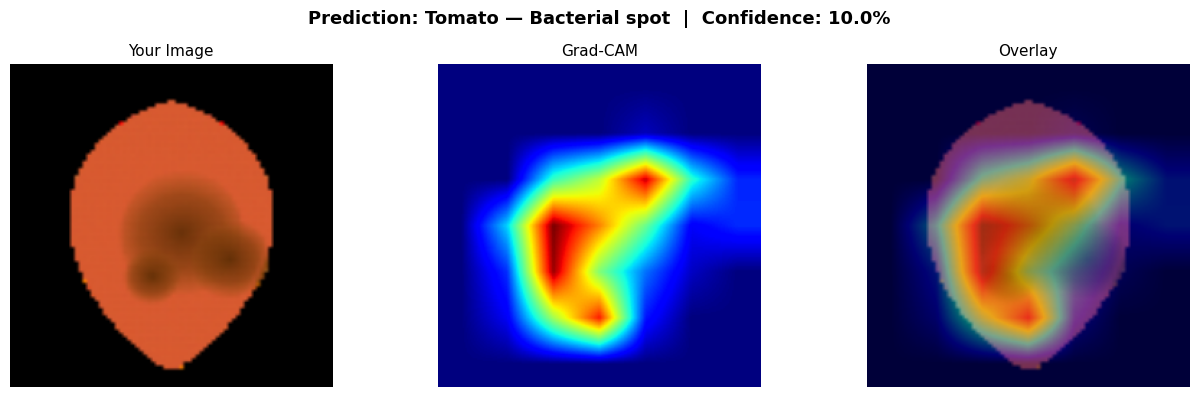


  PREDICTION: Tomato — Bacterial spot
  CONFIDENCE: 10.0%

  Top 5:
     10.0%  ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░  Tomato — Bacterial spot
      9.0%  ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░  Potato — Early blight
      8.8%  ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░  Apple — Apple scab
      8.0%  ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░  Potato — Late blight
      7.9%  ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░  Corn — healthy


In [15]:
# ── Step 12: Predict on your own image ───────────────────────────────────────
# Upload any leaf photo and get prediction + Grad-CAM
from google.colab import files as colab_files

print('Upload any leaf image (jpg/png):')
uploaded_img = colab_files.upload()

if uploaded_img:
    img_name = list(uploaded_img.keys())[0]
    original = np.array(Image.open(img_name).convert('RGB'))
    orig_rs  = cv2.resize(original, (IMG_SIZE, IMG_SIZE))

    tensor  = val_tf(image=orig_rs)['image'].unsqueeze(0).to(DEVICE)
    heatmap, pred_idx, probs = gradcam(tensor)

    top5_idx = probs.argsort()[::-1][:5]
    pred_name = CLASS_NAMES[pred_idx].replace('___',' — ').replace('_',' ')
    conf = probs[pred_idx]

    heat_col = cv2.applyColorMap((heatmap*255).astype(np.uint8), cv2.COLORMAP_JET)
    heat_col = cv2.cvtColor(heat_col, cv2.COLOR_BGR2RGB)
    overlay  = (0.45*heat_col + 0.55*orig_rs).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(orig_rs);  axes[0].set_title('Your Image',      fontsize=11); axes[0].axis('off')
    axes[1].imshow(heatmap, cmap='jet'); axes[1].set_title('Grad-CAM', fontsize=11); axes[1].axis('off')
    axes[2].imshow(overlay);  axes[2].set_title('Overlay',         fontsize=11); axes[2].axis('off')

    fig.suptitle(f'Prediction: {pred_name}  |  Confidence: {conf*100:.1f}%', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/results/my_prediction.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n' + '='*50)
    print(f'  PREDICTION: {pred_name}')
    print(f'  CONFIDENCE: {conf*100:.1f}%')
    print('\n  Top 5:')
    for idx in top5_idx:
        name = CLASS_NAMES[idx].replace('___',' — ').replace('_',' ')
        bar  = '█'*int(probs[idx]*30) + '░'*(30-int(probs[idx]*30))
        print(f'    {probs[idx]*100:5.1f}%  {bar}  {name}')
    print('='*50)

In [16]:
# ── Step 13: Download all results ────────────────────────────────────────────
from google.colab import files as colab_files
import zipfile

with zipfile.ZipFile('/content/cropguard_results.zip','w') as zf:
    for f in Path('/content/results').rglob('*'):
        if f.is_file(): zf.write(f, f.name)
    zf.write('/content/cropguard/models/best_model.pth', 'best_model.pth')

print('Downloading your results...')
colab_files.download('/content/cropguard_results.zip')
print('✅ Done! Check your Downloads folder for cropguard_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Done! Check your Downloads folder for cropguard_results.zip
